In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())

cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Partition-Optimal Pareto Frontiers vs. HBM Bandwidth

**Question:** how does the (throughput/GPU, interactivity) Pareto frontier shift as device HBM bandwidth grows, and which (PP, TP, EP, SP) partition wins at each frontier corner?

**Method:** for each HBM BW setting, sweep all valid (PP, TP, EP, SP) partitions × batch sizes B, keep the upper-right envelope in (tput/GPU, 1/TPOT) space, and record the winning partition at each frontier point.

Scale-up I/O and peak FLOPS are held fixed — only the HBM roofline slope varies. An *ideal-memory* reference (HBM BW → ∞) gives the compute + scale-up ceiling: the best achievable if weight reads were free.

Model, system, and tuner are configured in Section 1 — swap the database paths there to study a different setup.

## 1. Imports and spec loading

In [2]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec
from llm_perf.specs.system_spec import span_tiers

# Configuration — matches the NVIDIA inference blog (GPT-1.8T MoE @ FP4,
# GB200 NVL72). Swap these paths to study a different model/system.
MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.72gpu.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5  # GB200 inference precision.

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

base_hbm = system.device.hbm_bandwidth_GBps
base_up_alpha, base_up_bw, _ = span_tiers(system.get_tier_chain('TP'), 2)
peak_tf = system.device.peak_flops_TF
print(f"Model: {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  bytes/param={model.bytes_per_param}")
print(f"System: {system.num_devices} GPUs  HBM={base_hbm:.0f} GB/s  peak={peak_tf:.0f} TF  scale-up={base_up_bw:.0f} GB/s · {base_up_alpha:.2f} μs")

Model: GPT-1.8T-MoE  L=120  H=20480  n_kv=16  bytes/param=0.5
System: 72 GPUs  HBM=8000 GB/s  peak=9000 TF  scale-up=900 GB/s · 0.50 μs


## 2. Partition enumeration

GPT-1.8T MoE imposes divisibility constraints: `PP | L=120`, `TP | n_kv=16` and `H=20480`, `EP | n_experts=16`. We keep `SP=1`. Candidates exceeding 72 GPUs are dropped.

In [3]:
from llm_perf.utils import (
    enumerate_partitions as _enumerate_partitions,
    describe_constraints,
)


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    """Local shim around llm_perf.utils.enumerate_partitions; pins (model, system).

    Constraints applied: PP <= 16; TP <= min(n_kv, n_experts); EP <= n_experts
    (or 1 for dense); TP*EP <= scale_up_domain_size(system); pp*tp*ep*sp <= num_devices.
    See `llm_perf/utils/partition_enum.py` for the full derivation.
    """
    return _enumerate_partitions(model, system, num_devices=num_devices)


print(describe_constraints(model, system))

partitions = enumerate_partitions(system.num_devices)
print(f"Valid partitions: {len(partitions)}")

PP ≤ 16; TP ≤ min(n_kv=16, n_experts=16) = 16; EP ≤ n_experts=16; TP·EP ≤ scale_up=72 (tier_idx=0)
Valid partitions: 290


## 3. Partition sweep + Pareto frontier helpers

For each partition we derive `B_max` from the KV paging model and sweep log-spaced batch sizes. Each evaluation produces a point in (tput/GPU, 1/TPOT) space. We then walk the points in order of decreasing tput/GPU and keep those that strictly improve interactivity — the upper-right envelope.

In [4]:
@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep_partition(model, system, partition, tuner_base) -> list[Point]:
    try:
        mem = compute_memory(model, system, partition, tuner_base)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_base, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []

    pts: list[Point] = []
    for B in log_spaced_batch_sizes(b_max):
        tuner = deepcopy(tuner_base)
        tuner.B_decode = B
        try:
            r = InferenceCalculator(model, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            partition=partition,
            B=B,
            tput_per_gpu=r.latency.TTPS / system.num_devices,
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
        ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier

## 4. HBM bandwidth scaling helper

Only the device's HBM bandwidth is scaled. Scale-up I/O (TP/EP/SP/PP collectives) and peak FLOPS are held fixed so we isolate the memory-roofline effect.

In [5]:
def scale_system_hbm_bw(base_system, bw_mult: float):
    s = deepcopy(base_system)
    s.device.hbm_bandwidth_GBps *= bw_mult
    return s


def frontier_for_hbm(model, base_system, partitions, tuner_base,
                     hbm_mult: float) -> list[Point]:
    sys_m = scale_system_hbm_bw(base_system, hbm_mult)
    all_pts: list[Point] = []
    for part in partitions:
        all_pts.extend(sweep_partition(model, sys_m, part, tuner_base))
    return pareto_frontier(all_pts)

## 5. Run the sweeps

Improvement-only sweep: HBM BW stays ≥ 1× base. Anchors:

- `1.0×` — baseline GB200 HBM3E (8 TB/s).
- `1.5×` — plausible near-term HBM refresh (12 TB/s).
- `2.0×` — HBM4 class (16 TB/s).
- `3.0×` — HBM4 aggressive (24 TB/s, GB300-class).
- `4.0×` — DRAM-3D / HBM4E optimistic ceiling (32 TB/s).

**Ideal memory reference** — HBM BW → ∞: the compute + scale-up ceiling.

In [6]:
HBM_MULTIPLIERS = [1.0, 1.5, 2.0, 3.0, 4.0]

hbm_frontiers: dict[str, list[Point]] = {}
for mult in HBM_MULTIPLIERS:
    abs_bw = mult * base_hbm
    label = f"HBM={abs_bw/1000:.1f} TB/s  ({mult:g}× base)"
    print(f"[HBM] {label} ...")
    hbm_frontiers[label] = frontier_for_hbm(model, system, partitions, tuner_base, mult)

print("[ideal memory] HBM BW → ∞ ...")
ideal_mem_frontier = frontier_for_hbm(model, system, partitions, tuner_base, hbm_mult=1e6)

print(f"\nFrontiers computed: {len(hbm_frontiers)} HBM × 1 ideal")

[HBM] HBM=8.0 TB/s  (1× base) ...


[HBM] HBM=12.0 TB/s  (1.5× base) ...


[HBM] HBM=16.0 TB/s  (2× base) ...


[HBM] HBM=24.0 TB/s  (3× base) ...


[HBM] HBM=32.0 TB/s  (4× base) ...


[ideal memory] HBM BW → ∞ ...



Frontiers computed: 5 HBM × 1 ideal


## 6. Winners summary

For each frontier we count how many of its points are won by each (PP, TP, EP, SP) partition. A single-partition frontier means that shape is robust across batch corners; diversity means different partitions win at different corners.

In [7]:
def winners(frontier: list[Point]) -> list[tuple[str, int]]:
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    return sorted(counts.items(), key=lambda kv: -kv[1])


def print_winners(title: str, frontiers: dict[str, list[Point]]):
    print(f"── {title} " + "─" * max(0, 64 - len(title)))
    for label, fr in frontiers.items():
        w = winners(fr)
        top = ", ".join(f"{k} ({v})" for k, v in w)
        print(f"  {label}")
        print(f"    winners: {top}")


print_winners("HBM BW sweep", hbm_frontiers)
print()
print("── Ideal memory (HBM BW → ∞) " + "─" * 40)
for k, v in winners(ideal_mem_frontier):
    print(f"  {k}: {v}")

── HBM BW sweep ────────────────────────────────────────────────────
  HBM=8.0 TB/s  (1× base)
    winners: PP=15 TP=4 EP=1 SP=1 (19), PP=8 TP=8 EP=1 SP=1 (15), PP=12 TP=2 EP=1 SP=1 (4)
  HBM=12.0 TB/s  (1.5× base)
    winners: PP=15 TP=4 EP=1 SP=1 (13), PP=12 TP=2 EP=1 SP=1 (4), PP=4 TP=16 EP=1 SP=1 (1), PP=6 TP=8 EP=1 SP=1 (1), PP=8 TP=8 EP=1 SP=1 (1)
  HBM=16.0 TB/s  (2× base)
    winners: PP=15 TP=4 EP=1 SP=1 (9), PP=12 TP=2 EP=1 SP=1 (5), PP=3 TP=16 EP=1 SP=1 (1), PP=4 TP=16 EP=1 SP=1 (1), PP=6 TP=8 EP=1 SP=1 (1), PP=8 TP=8 EP=1 SP=1 (1)
  HBM=24.0 TB/s  (3× base)
    winners: PP=15 TP=4 EP=1 SP=1 (6), PP=12 TP=2 EP=1 SP=1 (5), PP=3 TP=8 EP=1 SP=1 (1), PP=4 TP=8 EP=1 SP=1 (1), PP=6 TP=4 EP=1 SP=1 (1), PP=8 TP=8 EP=1 SP=1 (1)
  HBM=32.0 TB/s  (4× base)
    winners: PP=15 TP=1 EP=1 SP=1 (12), PP=12 TP=2 EP=1 SP=1 (8), PP=15 TP=4 EP=1 SP=1 (2), PP=4 TP=8 EP=1 SP=1 (1), PP=6 TP=4 EP=1 SP=1 (1), PP=8 TP=4 EP=1 SP=1 (1)

── Ideal memory (HBM BW → ∞) ─────────────────────────────────────

## 7. Pareto plot

X = interactivity (1/TPOT), Y = throughput/GPU — matches the NVIDIA inference-blog convention.

Saved -> assets/pareto_vs_mem.png


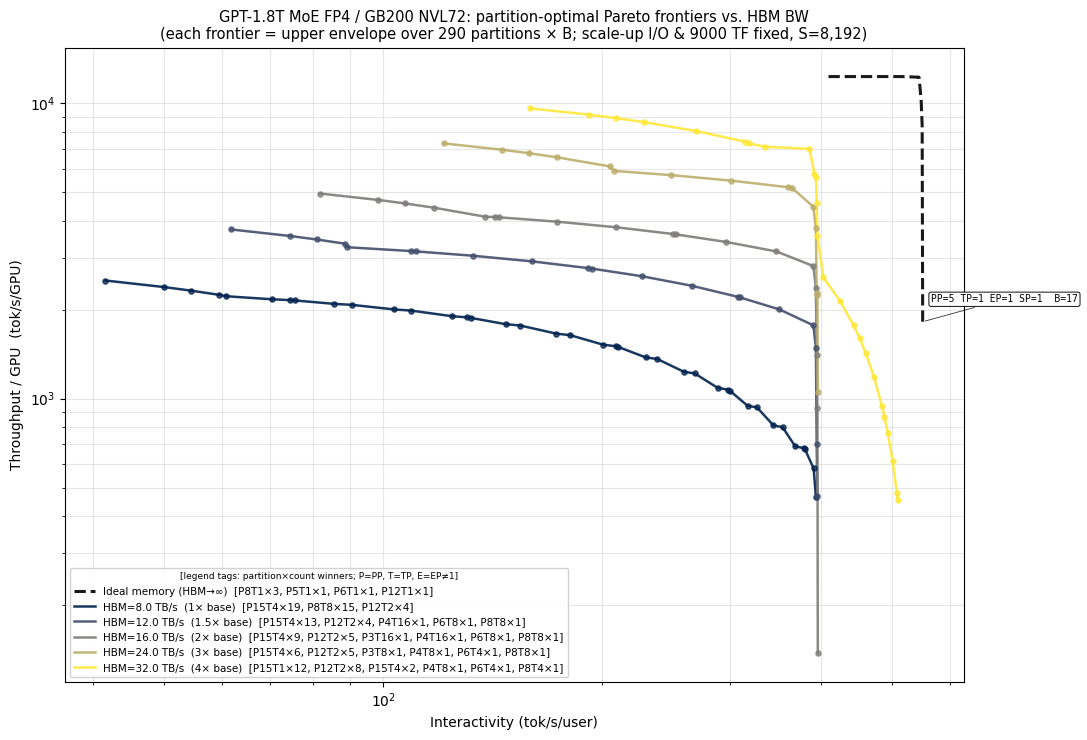

In [8]:
def winners_tag(frontier: list[Point]) -> str:
    """Compact label for legend: P=PP T=TP E=EP (drops EP=1 SP=1)."""
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    def short(name: str) -> str:
        return (name.replace(" EP=1", "").replace(" SP=1", "")
                    .replace("PP=", "P").replace("TP=", "T")
                    .replace("EP=", "E").replace(" ", ""))
    items = sorted(counts.items(), key=lambda kv: -kv[1])
    return ", ".join(f"{short(k)}×{v}" for k, v in items)


def annotate_ideal(ax, frontier, color="black"):
    if not frontier:
        return
    seen: set[str] = set()
    picks: list[int] = []
    for i, p in enumerate(frontier):
        if p.part_label not in seen:
            seen.add(p.part_label); picks.append(i)
    min_log_dx = 0.30
    last_logx = -math.inf
    kept: list[int] = []
    for idx in picks:
        lx = math.log10(max(1e-9, frontier[idx].interactivity))
        if lx - last_logx >= min_log_dx:
            kept.append(idx); last_logx = lx
    offsets = [(6, 14), (6, -20), (6, 32), (6, -38)]
    for j, idx in enumerate(kept):
        p = frontier[idx]
        dx, dy = offsets[j % len(offsets)]
        ax.annotate(
            f"{p.part_label}  B={p.B}",
            xy=(p.interactivity, p.tput_per_gpu),
            xytext=(dx, dy), textcoords="offset points",
            fontsize=7, family="monospace", color="black", ha="left",
            bbox=dict(boxstyle="round,pad=0.22", fc="white",
                      ec=color, alpha=0.95, lw=0.7),
            arrowprops=dict(arrowstyle="-", color=color, lw=0.6, alpha=0.8),
        )


fig, ax = plt.subplots(figsize=(11, 7.5))
cmap = plt.get_cmap("cividis")
labels = list(hbm_frontiers.keys())
colors = [cmap(i / max(1, len(labels) - 1)) for i in range(len(labels))]

if ideal_mem_frontier:
    ax.plot([p.interactivity for p in ideal_mem_frontier],
            [p.tput_per_gpu for p in ideal_mem_frontier],
            "--", lw=2.2, color="black", alpha=0.9,
            label=f"Ideal memory (HBM→∞)  [{winners_tag(ideal_mem_frontier)}]", zorder=6)

for (label, fr), color in zip(hbm_frontiers.items(), colors):
    if not fr:
        continue
    ax.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
            "-", lw=1.8, color=color, alpha=0.9,
            label=f"{label}  [{winners_tag(fr)}]")
    ax.scatter([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
               s=14, color=color, alpha=0.75, zorder=3)

if ideal_mem_frontier:
    annotate_ideal(ax, ideal_mem_frontier, "black")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Interactivity (tok/s/user)")
ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
ax.set_title(
    f"GPT-1.8T MoE FP4 / GB200 NVL72: partition-optimal Pareto frontiers vs. HBM BW\n"
    f"(each frontier = upper envelope over {len(partitions)} partitions × B; "
    f"scale-up I/O & {peak_tf:.0f} TF fixed, S={S_DECODE:,})",
    fontsize=10.5,
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(
    loc="lower left", fontsize=7.5, framealpha=0.9,
    title="[legend tags: partition×count winners; P=PP, T=TP, E=EP≠1]",
    title_fontsize=6.5,
)
fig.tight_layout()
fig.savefig("assets/pareto_vs_mem.png", dpi=130, bbox_inches="tight")
print("Saved -> assets/pareto_vs_mem.png")
plt.show()

## 8. What to take away

- At the baseline (1× HBM), weight reads are the dominant bottleneck for this model — the frontier is dragged inward on both axes vs. the ideal-memory ceiling.
- As HBM BW grows, the frontier marches toward the ideal-memory reference and the **winning partition can shift**: scarce HBM favors wide TP to parallelize weight reads across GPUs; abundant HBM makes the TP collective pure overhead, so shallower pipelines and smaller TP take over.
- The ideal-memory curve isolates what's left after memory is free — the residual gap vs. realistic frontiers is pure compute + scale-up I/O cost.
- If the winning partition at 4× HBM is materially different from the baseline, it's a signal that co-designing the partition with the memory hierarchy matters — a partition tuned for today's HBM may be wrong for a DRAM-3D future.